### 1) Problem Statement
- This project understands how the student's performance (test scores) is affected by other variables such as all other features (both categorical and numerical)


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Dataset reading

In [3]:
data=pd.read_csv('data/StudentsPerformance.csv')

In [4]:
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### converting into data frame

In [5]:
df=pd.DataFrame(data)


### Data preprocessing

In [6]:
df.shape

(1000, 8)

In [7]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [8]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df.duplicated().sum()

0

###  DataType checking

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### Statistics of dataset

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
df.nunique()  

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [15]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [18]:
print("categories in 'gender' variable:")
print(df['gender'].unique())
print("categories in 'race_ethnicity variable:")
print(df['race/ethnicity'].unique())
print("categories in 'parental level of education' variable:")
print(df['parental level of education'].unique())
print("categories in 'lunch' variable:")
print(df['lunch'].unique())
print("test preparation course' variable:")
print(df['test preparation course'].unique())




categories in 'gender' variable:
['female' 'male']
categories in 'race_ethnicity variable:
['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental level of education' variable:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' variable:
['standard' 'free/reduced']
test preparation course' variable:
['none' 'completed']


In [29]:
## dividing nmerical and categorical features
numerical_features=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']

# count of both categorical and numerical features
print("we have {} numerical features: {}".format(len(numerical_features),numerical_features))
print("we have {} categorical features: {}".format(len(categorical_features),categorical_features))





we have 3 numerical features: ['math score', 'reading score', 'writing score']
we have 5 categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [31]:
df['total_score']=df['math score']+df['reading score']+df['writing score']
df['average_score']=df['total_score']/3

In [32]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [51]:
## studets with full marks

reading_full=df[df['reading score']==100]['average_score'].count()
writing_full=df[df['writing score']==100]['average_score'].count()
math_full=df[df['math score']==100]['average_score'].count()


print("we have {} students have full score in math".format(math_full))
print("we have {} students have full score in reading".format(reading_full))
print("we have {} students have full score in writing".format(writing_full))




we have 7 students have full score in math
we have 17 students have full score in reading
we have 14 students have full score in writing


In [52]:
## less than or equal to 20

reading_full=df[df['reading score']<=20]['average_score'].count()
writing_full=df[df['writing score']<=20]['average_score'].count()
math_full=df[df['math score']<=20]['average_score'].count()


print("we have {} students have less that or equal to 20 score in math".format(math_full))
print("we have {} students have less that or equal to 20 score score in reading".format(reading_full))
print("we have {} students have less that or equal to 20 score score in writing".format(writing_full))



we have 4 students have less that or equal to 20 score in math
we have 1 students have less that or equal to 20 score score in reading
we have 3 students have less that or equal to 20 score score in writing


### visulaization using hist plots

In [62]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

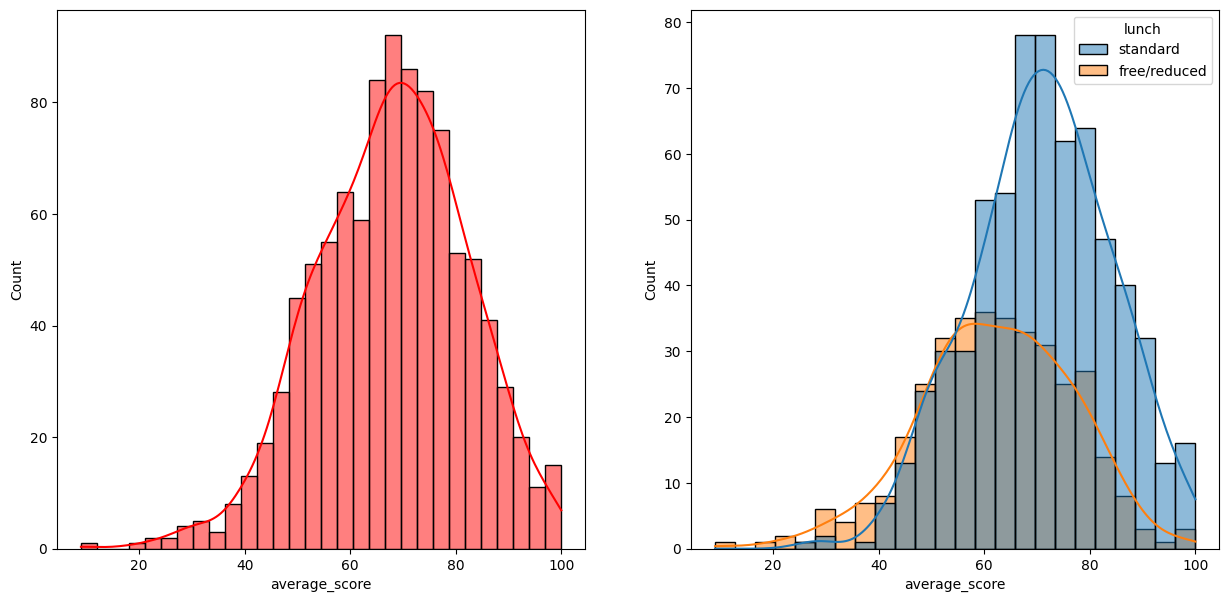

In [60]:
fig, axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='r')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='lunch')
plt.show()

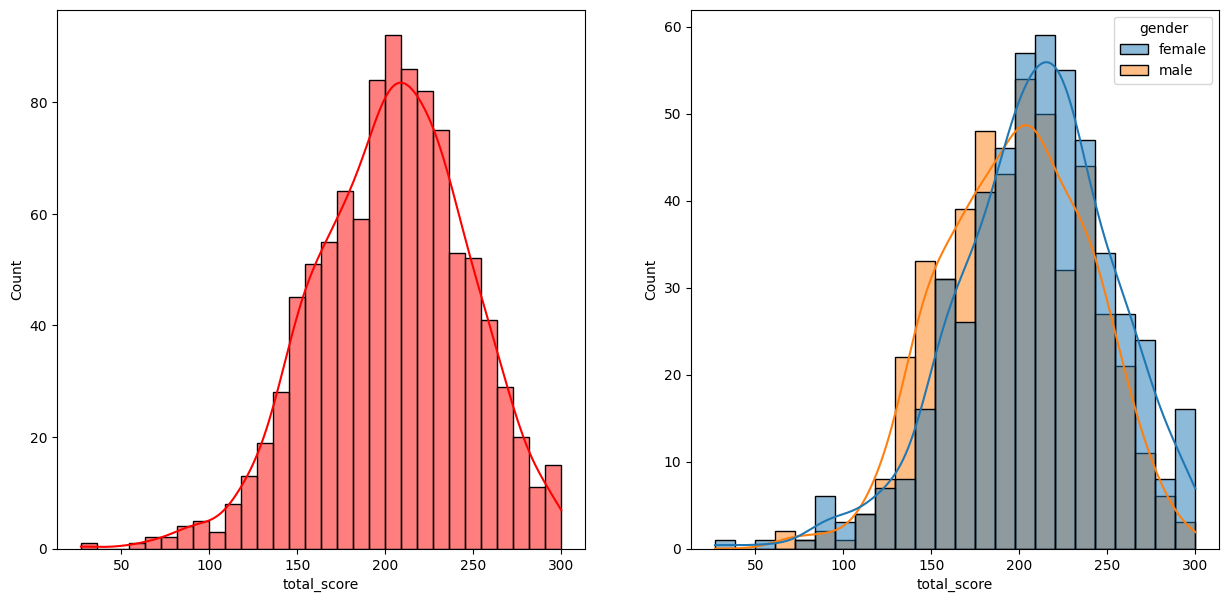

In [63]:
fig, axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='r')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

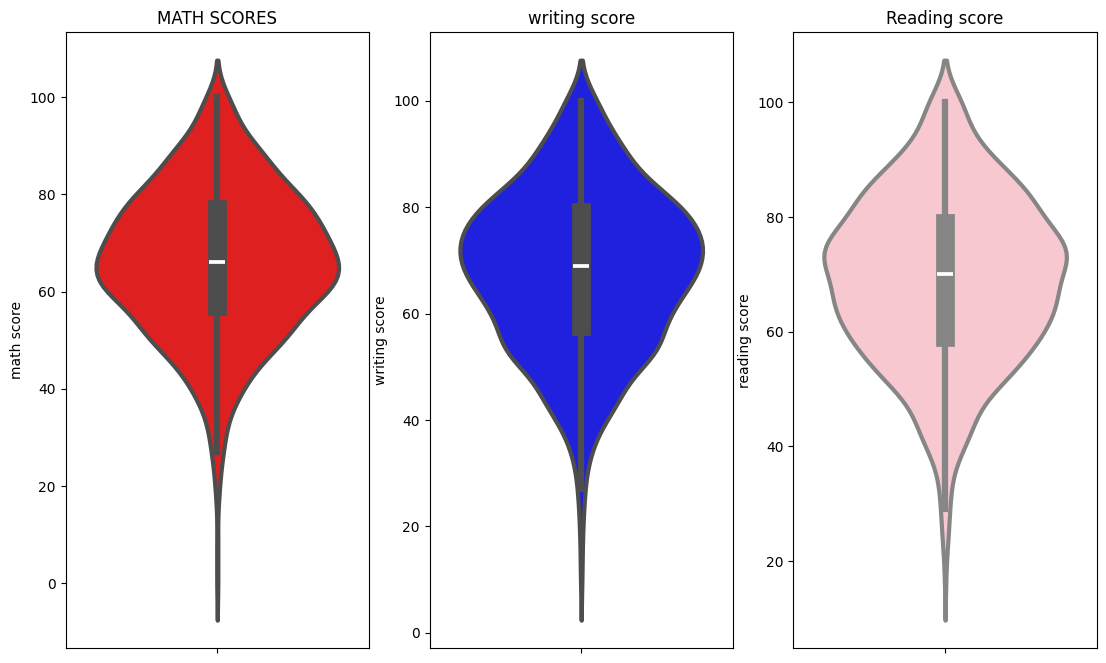

In [ ]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title("MATH SCORES")
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title("writing score")
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.subplot(1,4 ,3)
plt.title("Reading score")
sns.violinplot(y='reading score',data=df,color='pink',linewidth=3)
plt.show()

In [77]:
categorical_features

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course']

In [84]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [92]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

(-1.25, 1.25, -1.25, 1.25)

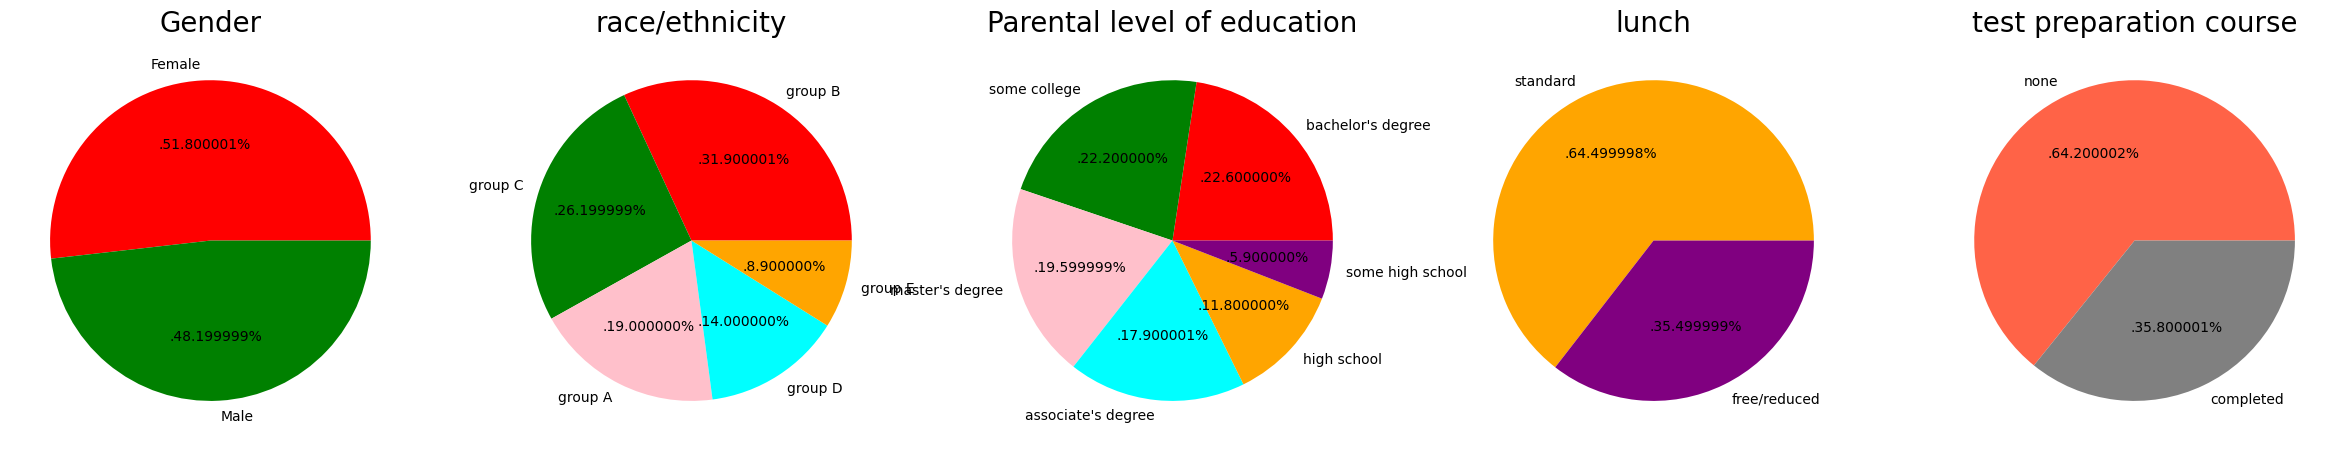

In [93]:
plt.rcParams['figure.figsize']=(30,12)

plt.subplot(1,5,1)
size=df['gender'].value_counts()
labels='Female','Male'
color=['red','green']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Gender',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size=df['race/ethnicity'].value_counts()
labels='group B', 'group C', 'group A', 'group D', 'group E'
color=['red','green','pink','cyan','orange']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('race/ethnicity',fontsize=20)
plt.axis('off')

plt.subplot(1,5,3)
size=df['parental level of education'].value_counts()
labels="bachelor's degree", 'some college', "master's degree","associate's degree", 'high school', 'some high school'
color=['red','green','pink','cyan','orange','purple']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Parental level of education',fontsize=20)
plt.axis('off')


plt.subplot(1,5,4)
size=df['lunch'].value_counts()
labels='standard', 'free/reduced'
color=['orange','purple']

plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('lunch',fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size=df['test preparation course'].value_counts()
labels='none', 'completed'
color=['tomato','grey']


plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('test preparation course',fontsize=20)
plt.axis('off')


### univariate analysis

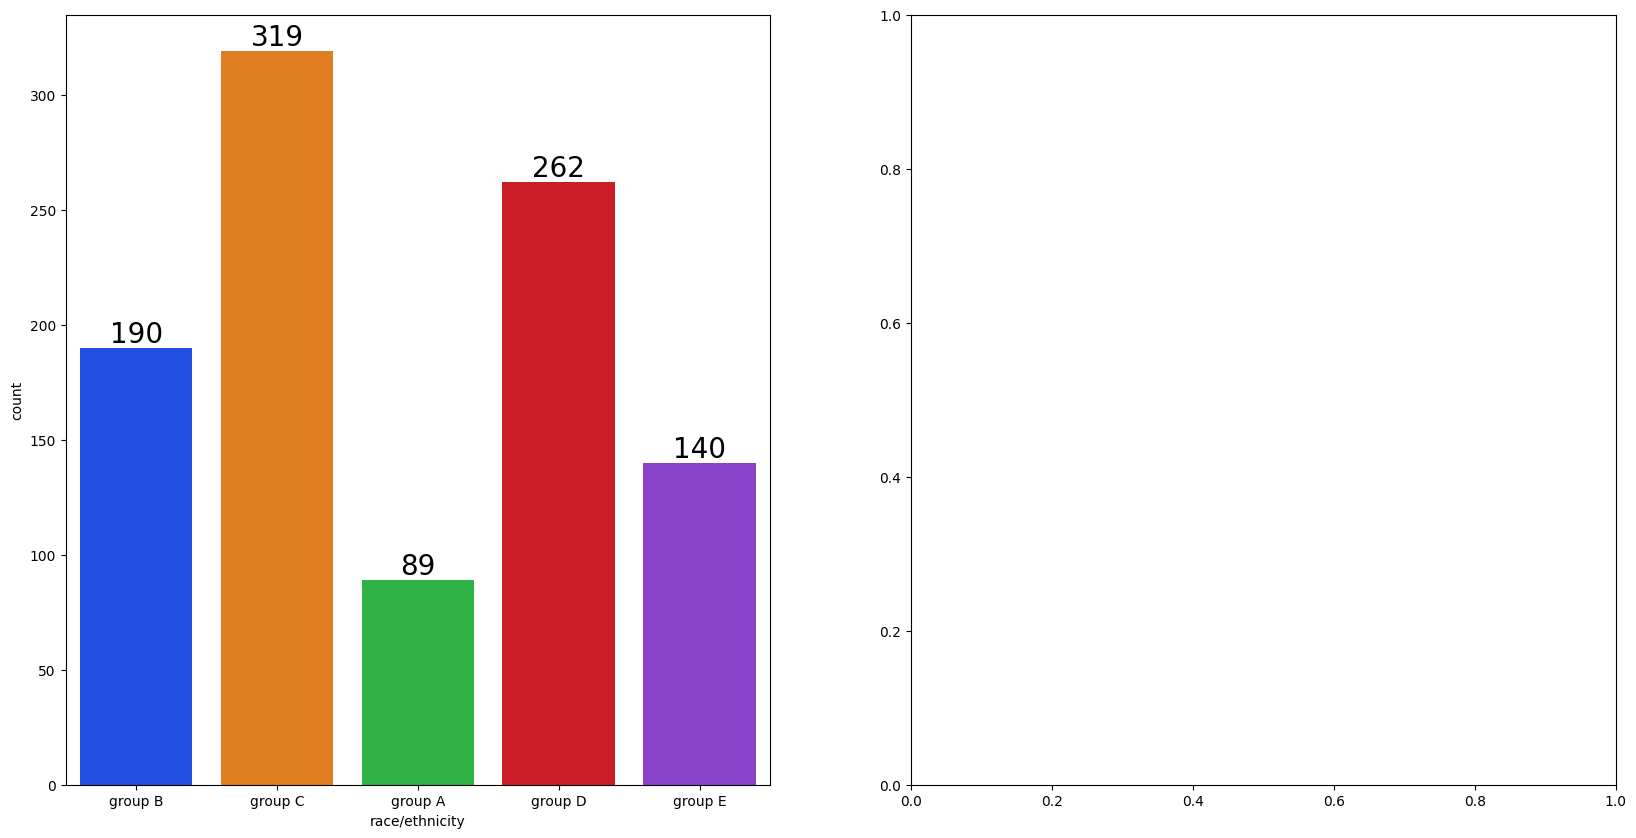

In [98]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette='bright',ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

In [101]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

### Bivariate Analysis

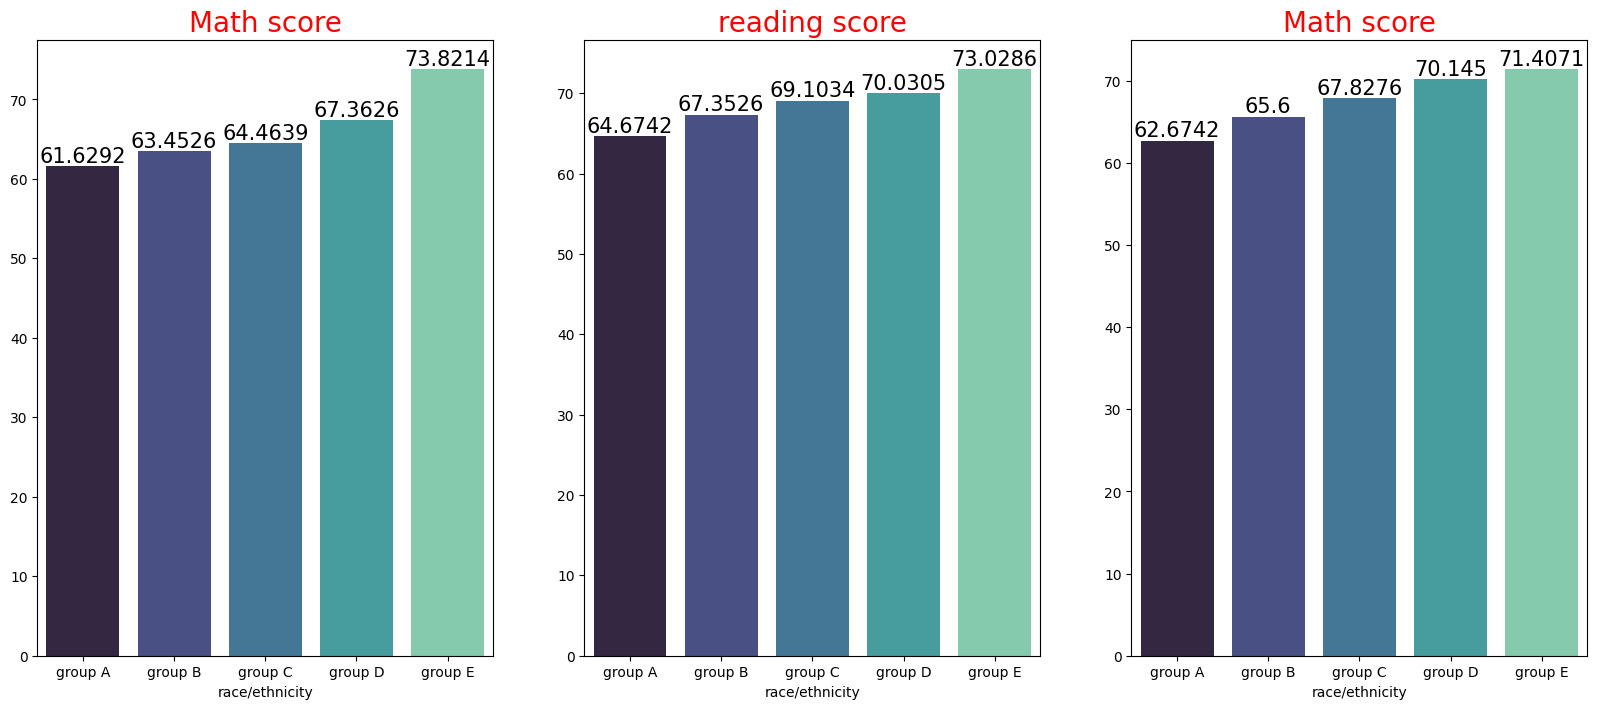

In [111]:
Group_data=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data['math score'].mean().index,y=Group_data['math score'].mean().values,palette='mako',ax=ax[0])
ax[0].set_title('Math score',color='red',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data['reading score'].mean().index,y=Group_data['reading score'].mean().values,palette='mako',ax=ax[1])
ax[1].set_title('reading score',color='red',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data['writing score'].mean().index,y=Group_data['writing score'].mean().values,palette='mako',ax=ax[2])
ax[2].set_title('Math score',color='red',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)


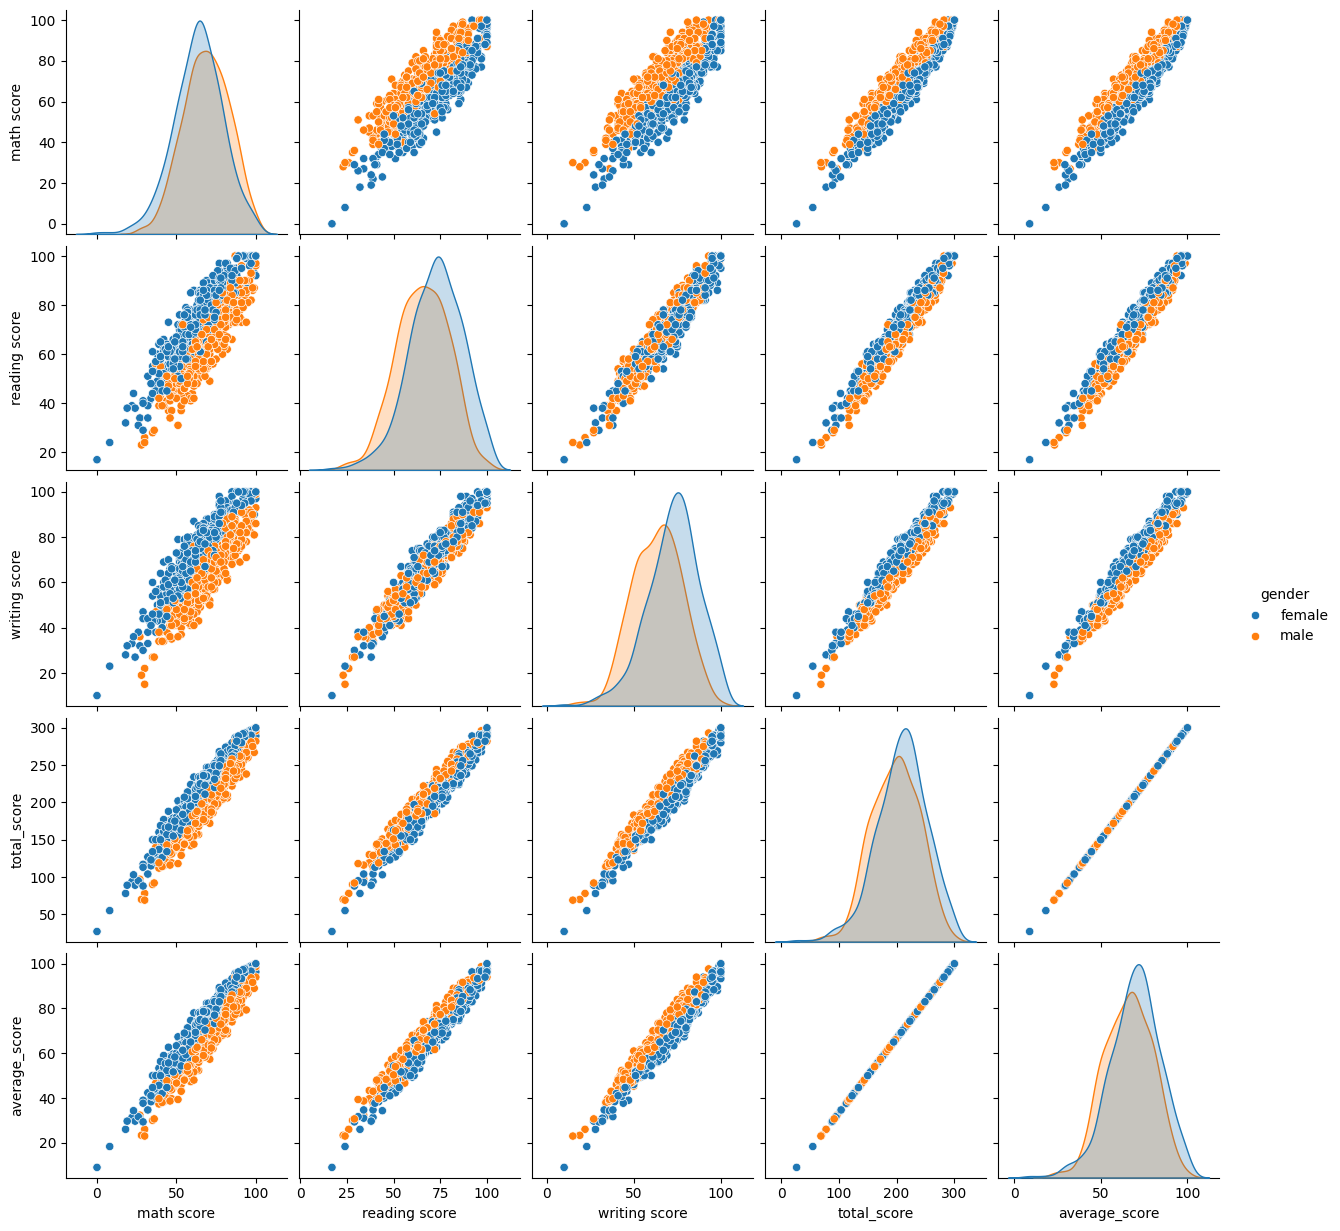

In [112]:
sns.pairplot(df,hue='gender')
plt.show()